# Proyecto Final — Análisis de Datos
## Predicción de la productividad de operarios en una fábrica textil

**Curso:** Análisis de Datos — ING0039 · Universidad de Montevideo

**Integrantes:** Azael Pignanessi · Facundo Sansalone

**Dataset:** *Garments Worker Productivity* (fábrica textil, Bangladesh) — `Tema_11.csv`

---

### Índice

1. [Descripción del problema](#1)
2. [Descripción del conjunto de datos](#2)
3. [Análisis exploratorio de datos (EDA)](#3)
4. [Pretratamiento de datos](#4)
5. [Análisis de datos mediante visualizaciones (PCA)](#5)
6. [Construcción del modelo predictivo](#6)
7. [Resultados obtenidos](#7)
8. [Conclusiones](#8)


In [ ]:
# Instalar dependencias (ejecutar solo si no están instaladas)
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

<a id="1"></a>
## 1. Descripción del problema

La industria textil de la confección es intensiva en mano de obra y su rentabilidad
depende fuertemente de la **productividad** de los equipos de operarios. Cada equipo
recibe diariamente una **meta de productividad** (`targeted_productivity`) y al cierre
de la jornada se mide la **productividad real alcanzada** (`actual_productivity`).

Para la gerencia de la fábrica resulta clave **entender qué factores del proceso de
producción influyen en la productividad real** y **poder anticiparla** a partir de las
condiciones del día (tamaño del equipo, horas extra, incentivos, tiempos muertos, trabajo
en proceso, etc.).

**Objetivo:** construir un modelo predictivo que estime la `actual_productivity` de un
equipo en una jornada dada, e identificar las variables más influyentes, para detectar
tempranamente equipos con riesgo de no cumplir su meta y dirigir acciones correctivas
(incentivos, redistribución de carga, reducción de tiempos muertos).

Se trata de un problema de **regresión supervisada**: la variable objetivo es continua
y está acotada al rango [0, 1].


<a id="2"></a>
## 2. Descripción del conjunto de datos

El dataset proviene de una fábrica textil de Bangladesh. Cada fila representa el registro
de **un equipo de trabajo en un día específico**, con 15 variables que agrupamos en tres
roles: **contexto temporal**, **variables predictoras** y la **variable objetivo**.

> **Nota:** la variable `team` identifica equipos (1–12) sin ningún orden inherente,
> por lo que se trata como **categórica**, no numérica.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_colwidth', 90)

df = pd.read_csv('Tema_11.csv')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')

Dimensiones: 1207 filas x 15 columnas


In [2]:
descripcion = pd.DataFrame({
    'Variable': ['date','quarter','department','day','team',
                 'targeted_productivity','smv','wip','over_time','incentive',
                 'idle_time','idle_men','no_of_style_change','no_of_workers',
                 'actual_productivity'],
    'Tipo':     ['Fecha','Categórica','Categórica','Categórica','Categórica',
                 'Continua','Continua','Continua','Continua','Continua',
                 'Continua','Discreta','Discreta','Continua','Continua'],
    'Rol':      ['Contexto','Contexto','Predictora','Predictora','Predictora',
                 'Predictora','Predictora','Predictora','Predictora','Predictora',
                 'Predictora','Predictora','Predictora','Predictora','OBJETIVO'],
    'Descripción': [
        'Fecha del registro (MM/DD/YYYY)',
        'Porción del mes: Quarter1 a Quarter5',
        'Departamento: sewing (costura) o finishing (acabado)',
        'Día de la semana',
        'Número de equipo (1–12) — categórica, sin orden inherente',
        'Meta de productividad asignada por la autoridad (0–1)',
        'Standard Minute Value: tiempo estándar para la tarea (min)',
        'Work In Progress: unidades iniciadas pero no terminadas',
        'Horas extra trabajadas por el equipo (minutos)',
        'Incentivo económico otorgado al equipo (BDT)',
        'Tiempo de interrupción de la producción (minutos)',
        'Trabajadores inactivos durante interrupciones',
        'Cantidad de cambios en el diseño del producto',
        'Total de trabajadores en el equipo',
        'Productividad real alcanzada (0–1) — OBJETIVO',
    ]
})
descripcion

,Variable,Tipo,Rol,Descripción
0,date,Fecha,Contexto,Fecha del registro (MM/DD/YYYY)
1,quarter,Categórica,Contexto,Porción del mes: Quarter1 a Quarter5
2,department,Categórica,Predictora,Departamento: sewing (costura) o finishing (acabado)
3,day,Categórica,Predictora,Día de la semana
4,team,Categórica,Predictora,"Número de equipo (1–12) — categórica, sin orden inherente"
5,targeted_productivity,Continua,Predictora,Meta de productividad asignada por la autoridad (0–1)
6,smv,Continua,Predictora,Standard Minute Value: tiempo estándar para la tarea (min)
7,wip,Continua,Predictora,Work In Progress: unidades iniciadas pero no terminadas
8,over_time,Continua,Predictora,Horas extra trabajadas por el equipo (minutos)
9,incentive,Continua,Predictora,Incentivo económico otorgado al equipo (BDT)


<a id="3"></a>
## 3. Análisis exploratorio de datos (EDA)

Exploramos dimensiones, tipos de dato, faltantes, duplicados, distribuciones e
inconsistencias **antes** de cualquier limpieza.

### 3a. Dimensiones y tipos de dato

In [3]:
print(f'Filas: {df.shape[0]}   Columnas: {df.shape[1]}')
print()
print(df.dtypes)

Filas: 1207   Columnas: 15

date                      object
quarter                   object
department                object
day                       object
team                      object
targeted_productivity    float64
smv                      float64
wip                      float64
over_time                float64
incentive                float64
idle_time                float64
idle_men                 float64
no_of_style_change       float64
no_of_workers            float64
actual_productivity      float64
dtype: object


### 3b. Estadísticas descriptivas

In [4]:
df.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8.0,0.80,26.16,1108.0,7080.0,98.0,0.0,0.0,0.0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1.0,0.75,3.94,NaN,960.0,0.0,0.0,0.0,0.0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11.0,0.80,11.41,968.0,3660.0,50.0,0.0,0.0,0.0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12.0,0.80,11.41,968.0,3660.0,50.0,0.0,0.0,NaN,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6.0,0.80,25.90,NaN,1920.0,50.0,0.0,0.0,0.0,56.0,NaN


In [5]:
df.describe()

,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1146.000000,1148.000000,668.000000,1149.000000,1147.000000,1146.000000,1147.000000,1147.000000,1147.000000,1147.000000
mean,0.728988,20.671272,1202.133234,5862.654482,38.871840,0.762653,0.326940,0.151700,34.598518,0.852642
std,0.099195,55.051234,1866.755181,13146.200215,163.488076,12.988774,3.034473,0.429704,22.189488,1.122498
min,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,0.700000,3.940000,783.750000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650899
50%,0.750000,15.260000,1043.000000,4080.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.779792
75%,0.800000,24.260000,1256.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850413
max,0.800000,545.600000,23122.000000,129600.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,11.204375


### 3c. Datos faltantes

In [6]:
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
res   = pd.DataFrame({'Faltantes': nulos, '%': pct})
res   = res[res['Faltantes'] > 0].sort_values('%', ascending=False)
print(res)
print(f'\nTotal celdas faltantes: {nulos.sum()}')

                       Faltantes      %
wip                          539  44.66
date                          62   5.14
day                           61   5.05
targeted_productivity         61   5.05
idle_time                     61   5.05
quarter                       60   4.97
department                    60   4.97
incentive                     60   4.97
idle_men                      60   4.97
no_of_style_change            60   4.97
no_of_workers                 60   4.97
actual_productivity           60   4.97
team                          59   4.89
smv                           59   4.89
over_time                     58   4.81

Total celdas faltantes: 1380


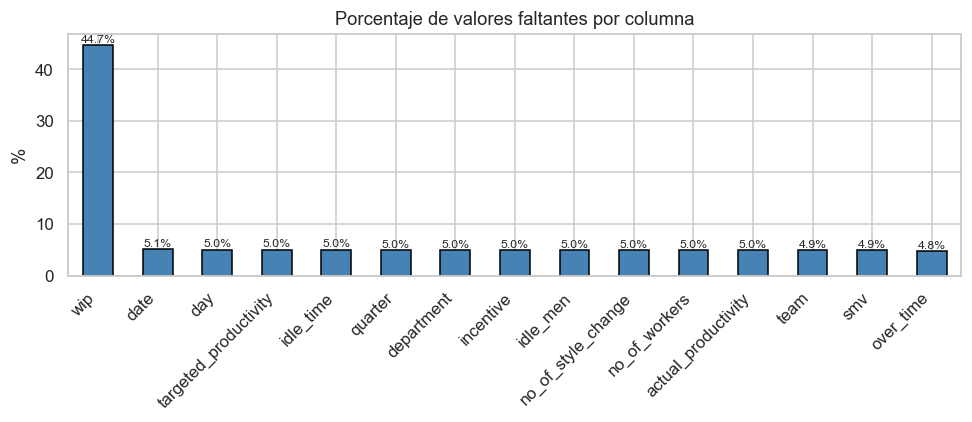

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
res['%'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Porcentaje de valores faltantes por columna')
ax.set_ylabel('%')
ax.set_xticklabels(res.index, rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height() + 0.1),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
n_dup = df.duplicated().sum()
print(f'Filas duplicadas: {n_dup} ({round(n_dup/len(df)*100,2)}%)')

Filas duplicadas: 10 (0.83%)


### 3d. Posibles motivos de datos faltantes

| Tipo | Significado | Variables |
|---|---|---|
| Estructural | No aplica en ese contexto | `wip` en *finishing* |
| Derivable | Recuperable desde otra columna | `day`, `quarter` desde `date` |
| Error de registro | Debería existir pero no fue cargado | `department`, `team`, `targeted_productivity`, `no_of_workers` |
| Posible cero | Faltante = ausencia del fenómeno | `incentive`, `idle_time`, `idle_men`, `no_of_style_change` |
| Sin medición | Variable objetivo no medida — no imputable | `actual_productivity` |

In [9]:
tmp = df.copy()
tmp['department'] = tmp['department'].str.strip()
print('wip nulo por departamento:')
print(tmp.groupby('department')['wip'].agg(
    total='count',
    faltantes=lambda x: x.isnull().sum(),
    pct_faltante=lambda x: f'{x.isnull().mean()*100:.1f}%'
))

wip nulo por departamento:
            total  faltantes pct_faltante
department                               
finishing       0        477       100.0%
sweing        642         28         4.2%


### 3e. Valores únicos de variables categóricas

In [10]:
# team incluida: es categórica (etiquetas sin orden)
vars_cat = ['quarter','department','day','team','no_of_style_change']
for col in vars_cat:
    cnt = df[col].value_counts(dropna=True).sort_index()
    print(f'--- {col} ({len(cnt)} valores únicos) ---')
    print(cnt.to_frame('Frecuencia').T)
    print()

--- quarter (5 valores únicos) ---
quarter     Quarter1  Quarter2  Quarter3  Quarter4  Quarter5
Frecuencia       339       320       203       246        39

--- department (3 valores únicos) ---
department  finishing  finishing   sweing
Frecuencia        233         244     670

--- day (6 valores únicos) ---
day         Monday  Saturday  Sunday  Thursday  Tuesday  Wednesday
Frecuencia     190       177     194       190      191        204

--- team (13 valores únicos) ---
team        1.0  10.0  11.0  12.0  2.0  3.0  4.0  5.0  6.0  7.0  8.0  9.0  \
Frecuencia   99    96    84    94   99   87  103   84   96   90  106   98   

team        invalid_value  
Frecuencia             12  

--- no_of_style_change (3 valores únicos) ---
no_of_style_change   0.0  1.0  2.0
Frecuencia          1005  110   32



### 3f. Distribuciones

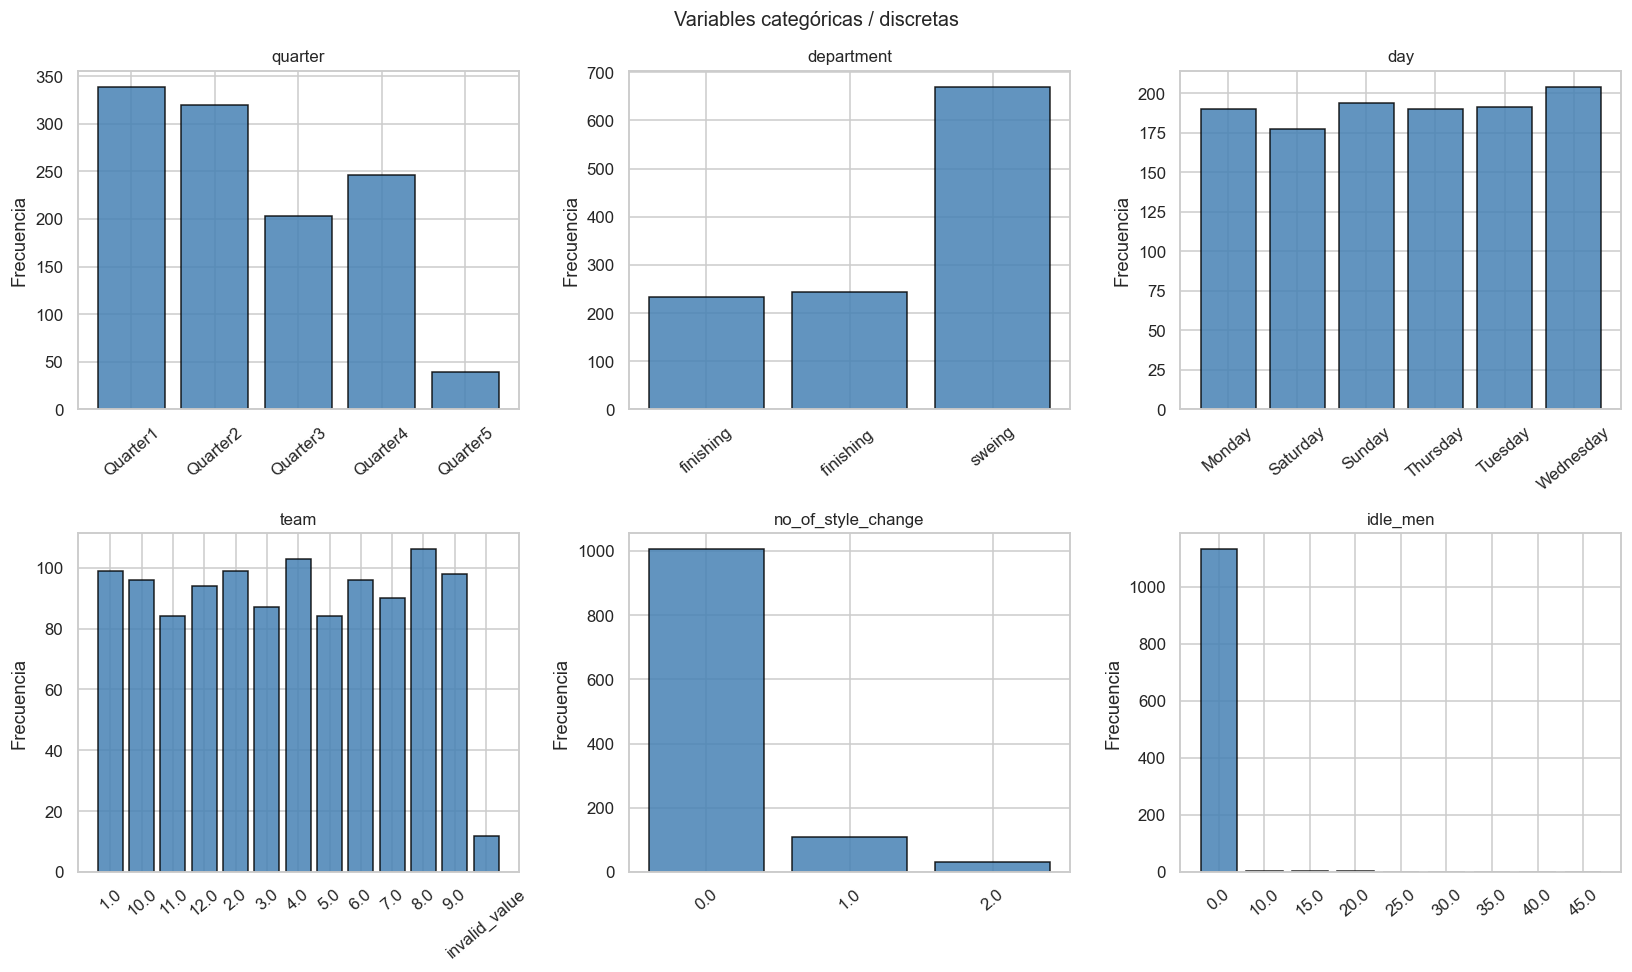

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for i, col in enumerate(['quarter','department','day','team','no_of_style_change','idle_men']):
    cnt = df[col].value_counts().sort_index()
    axes[i].bar(cnt.index.astype(str), cnt.values, color='steelblue', edgecolor='black', alpha=0.85)
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=40)
plt.suptitle('Variables categóricas / discretas', fontsize=13)
plt.tight_layout()
plt.show()

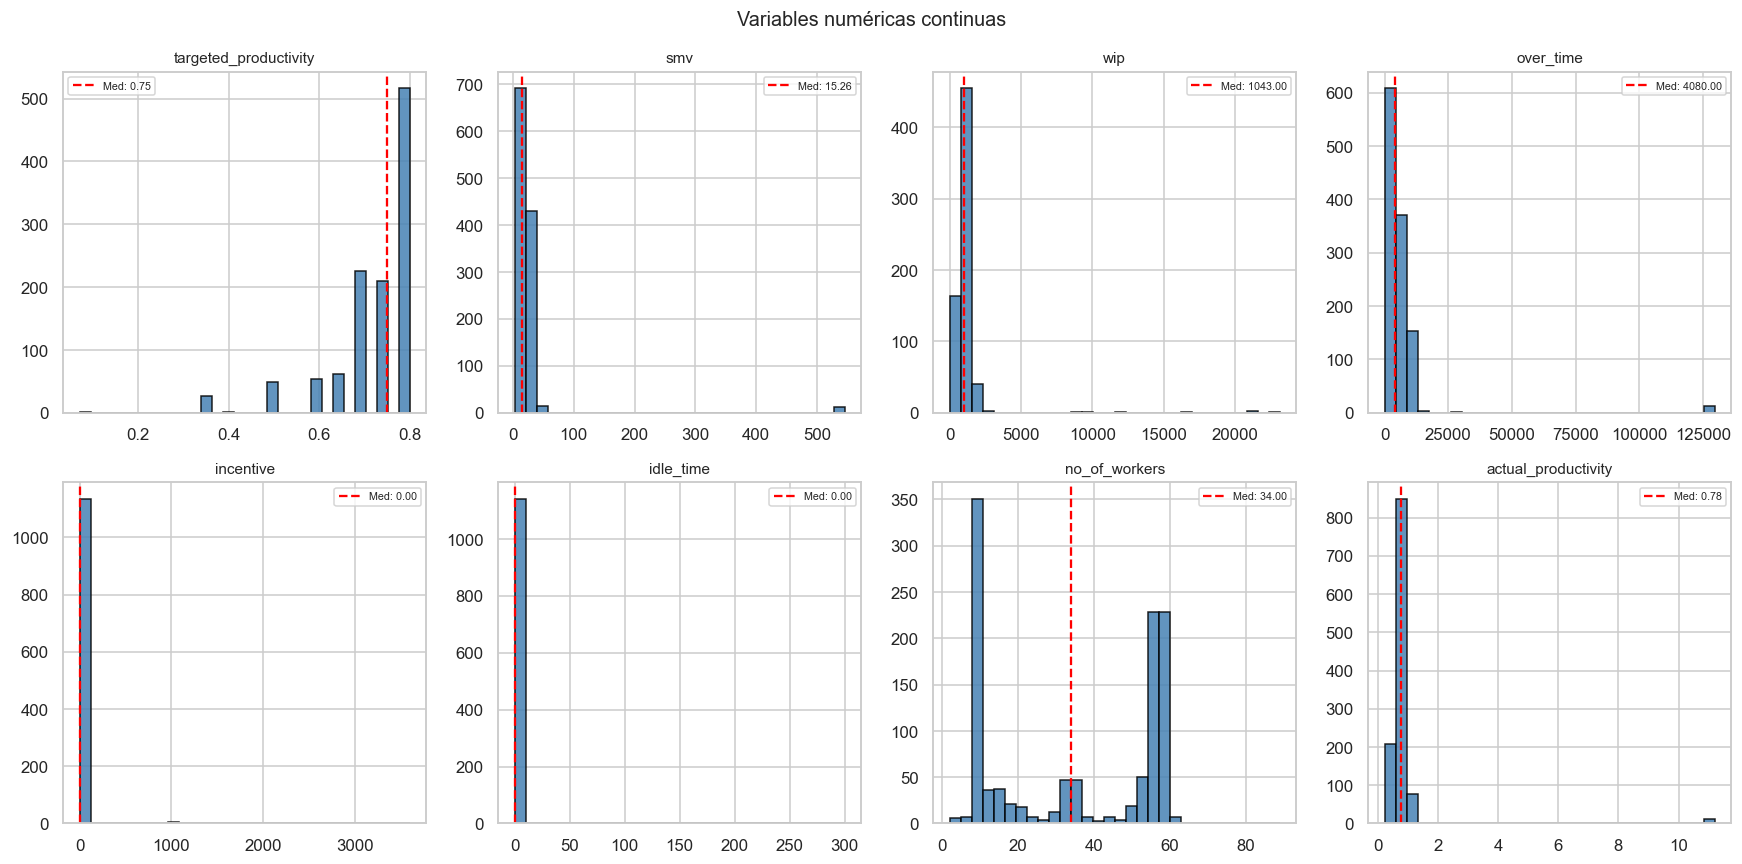

In [12]:
vars_cont = ['targeted_productivity','smv','wip','over_time',
             'incentive','idle_time','no_of_workers','actual_productivity']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(vars_cont):
    data = df[col].dropna()
    axes[i].hist(data, bins=30, color='steelblue', edgecolor='black', alpha=0.85)
    axes[i].axvline(data.median(), color='red', linestyle='--', lw=1.5,
                    label=f'Med: {data.median():.2f}')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)
plt.suptitle('Variables numéricas continuas', fontsize=13)
plt.tight_layout()
plt.show()

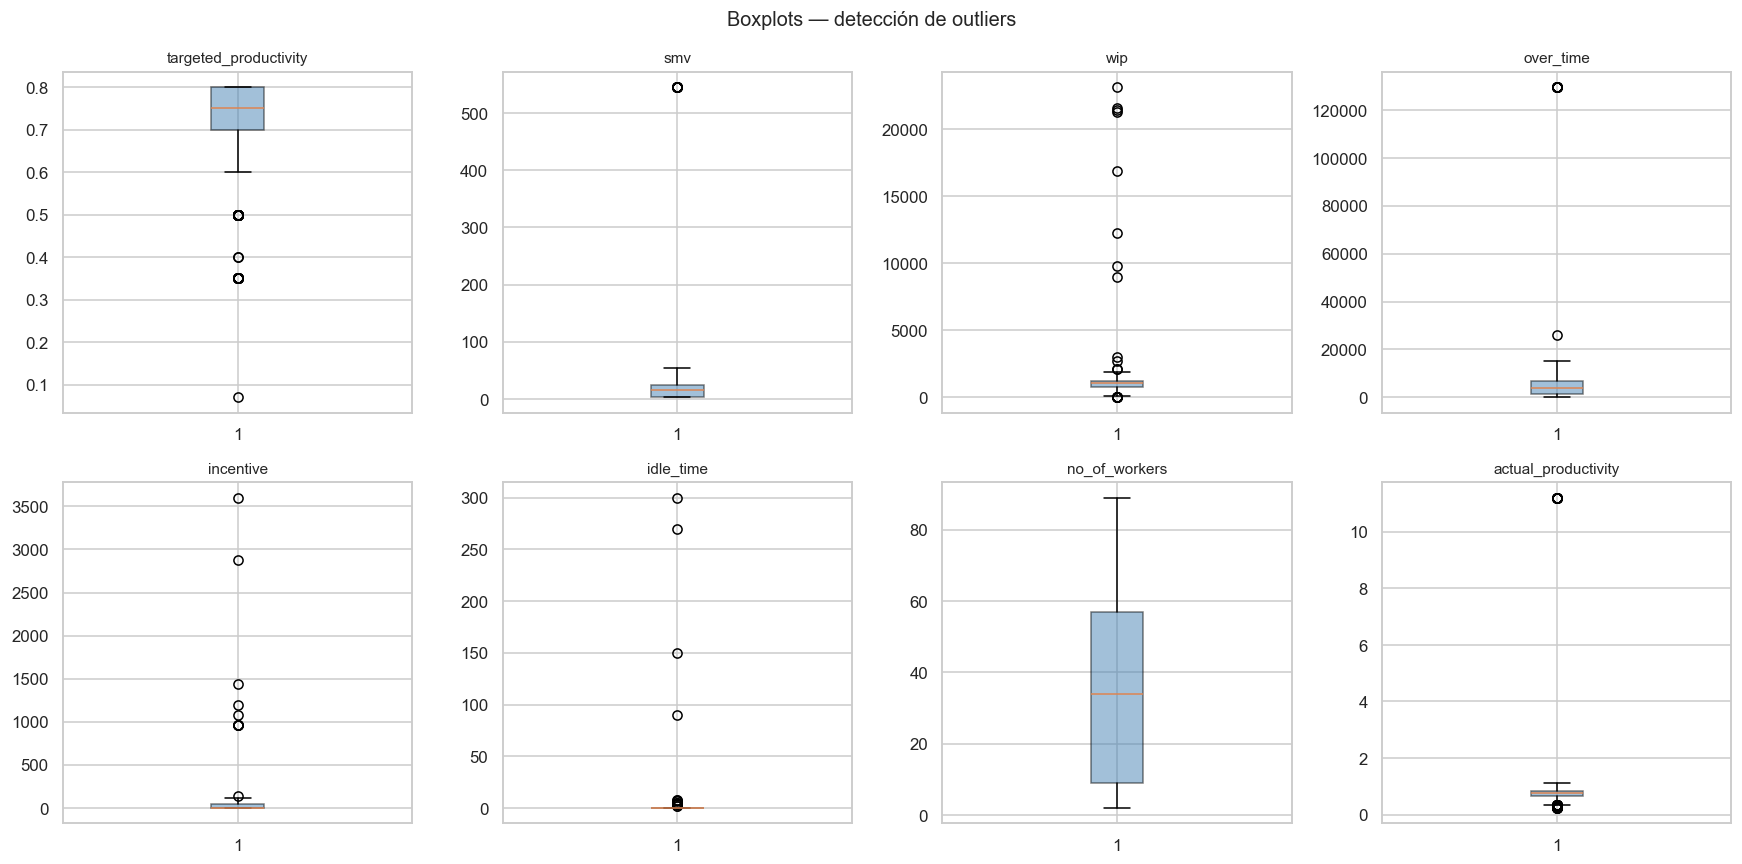

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(vars_cont):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.5))
    axes[i].set_title(col, fontsize=10)
plt.suptitle('Boxplots — detección de outliers', fontsize=13)
plt.tight_layout()
plt.show()

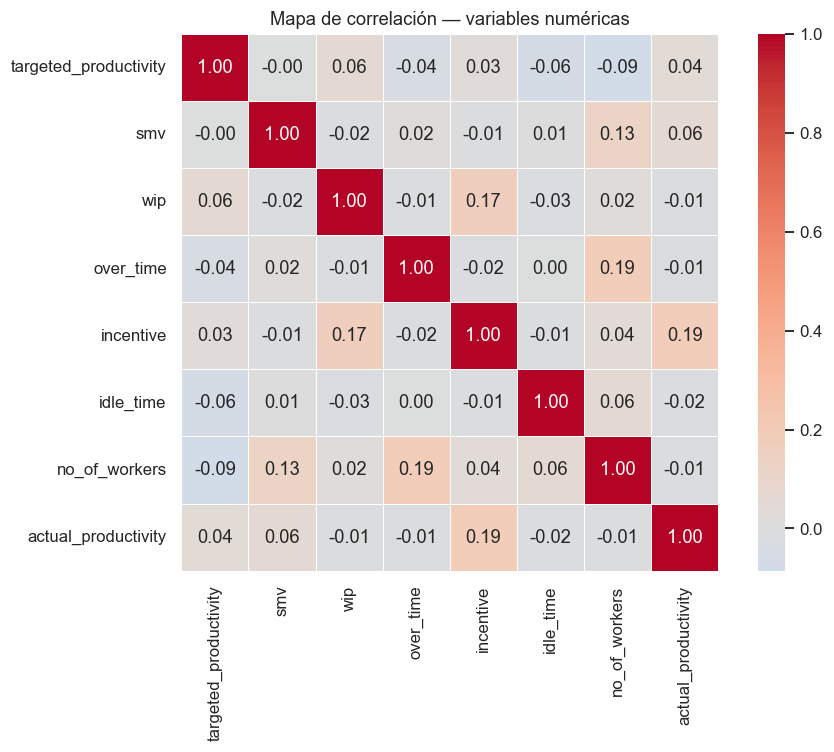

In [14]:
corr = df[vars_cont].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.4, ax=ax)
ax.set_title('Mapa de correlación — variables numéricas')
plt.tight_layout()
plt.show()

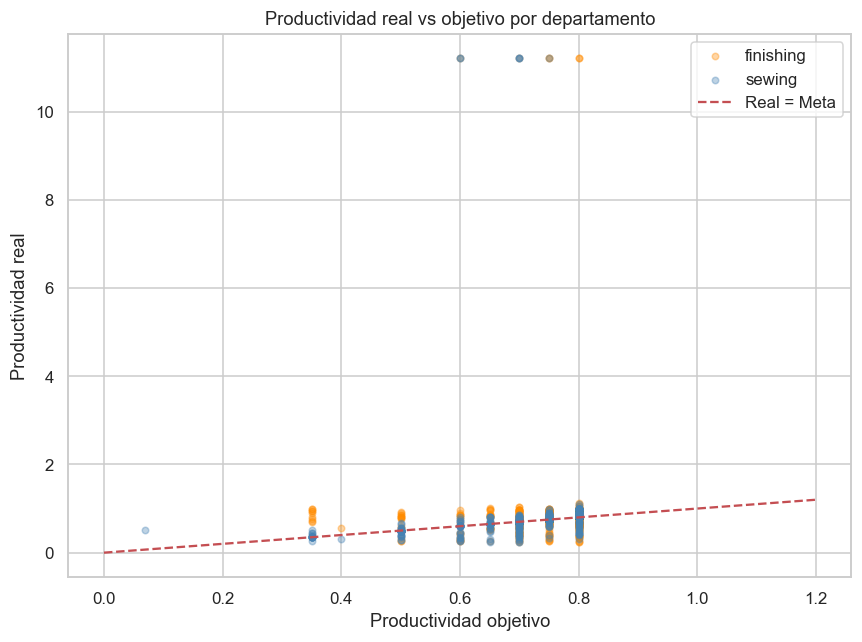

In [15]:
t = df.dropna(subset=['department','actual_productivity','targeted_productivity']).copy()
t['dept'] = t['department'].str.strip().replace('sweing','sewing')
fig, ax = plt.subplots(figsize=(8, 6))
for dept, grp in t.groupby('dept'):
    ax.scatter(grp['targeted_productivity'], grp['actual_productivity'],
               label=dept, alpha=0.35, s=18,
               color='steelblue' if dept=='sewing' else 'darkorange')
ax.plot([0, 1.2], [0, 1.2], 'r--', lw=1.5, label='Real = Meta')
ax.set_xlabel('Productividad objetivo'); ax.set_ylabel('Productividad real')
ax.set_title('Productividad real vs objetivo por departamento')
ax.legend(); plt.tight_layout(); plt.show()

### 3g. Datos inconsistentes detectados

In [16]:
# 1. Texto en 'team'
inv = df[pd.to_numeric(df['team'], errors='coerce').isnull() & df['team'].notna()]
print(f'[1] Valores no numéricos en team: {len(inv)}')
print(inv[['date','department','day','team']].to_string())

# 2. Typos en 'department'
print('\n[2] Valores únicos en department (sin limpiar):')
print(df['department'].value_counts().to_string())

# 3. actual_productivity fuera de [0,1]
fuera = df[(df['actual_productivity'] < 0) | (df['actual_productivity'] > 1)]
print(f'\n[3] actual_productivity fuera de [0,1]: {len(fuera)} registros')

# 4. smv extremo
print('\n[4] smv > 100 min:')
print(df[df['smv'] > 100][['date','department','team','smv']].to_string())

# 5. over_time imposible
print('\n[5] over_time > 25 000 min (>17 días):')
print(df[df['over_time'] > 25000][['date','department','team','over_time']].to_string())

[1] Valores no numéricos en team: 12
          date  department        day           team
34    1/3/2015      sweing   Saturday  invalid_value
104   1/7/2015  finishing   Wednesday  invalid_value
229  1/13/2015         NaN    Tuesday  invalid_value
372  1/22/2015  finishing    Thursday  invalid_value
378  1/22/2015      sweing   Thursday  invalid_value
384  1/22/2015  finishing    Thursday  invalid_value
438  1/26/2015  finishing      Monday  invalid_value
537  1/31/2015      sweing   Saturday  invalid_value
547   2/1/2015  finishing      Sunday  invalid_value
633   2/5/2015      sweing   Thursday  invalid_value
771  2/15/2015   finishing     Sunday  invalid_value
923  2/25/2015   finishing  Wednesday  invalid_value

[2] Valores únicos en department (sin limpiar):
department
sweing        670
finishing     244
finishing     233

[3] actual_productivity fuera de [0,1]: 48 registros

[4] smv > 100 min:
           date  department           team    smv
25     1/3/2015      sweing         

In [17]:
pd.DataFrame([
    ('team = invalid_value',      '1 fila',    'Texto en columna numérica'),
    ('department: espacio+typo',  'Todo el set','Trailing space y "sweing" vs "sewing"'),
    ('smv = 545.6 min',           '1 fila',    'Outlier extremo (~28× la mediana)'),
    ('over_time = 129 600 min',   '1 fila',    'Equivale a ~90 días laborales, imposible'),
    ('Valores negativos',         '0 filas',   'No detectados'),
], columns=['Inconsistencia','Alcance','Descripción'])

,Inconsistencia,Alcance,Descripción
0,team = invalid_value,1 fila,Texto en columna numérica
1,department: espacio+typo,Todo el set,"Trailing space y ""sweing"" vs ""sewing"""
2,smv = 545.6 min,1 fila,Outlier extremo (~28× la mediana)
3,over_time = 129 600 min,1 fila,"Equivale a ~90 días laborales, imposible"
4,Valores negativos,0 filas,No detectados


<a id="4"></a>
## 4. Pretratamiento de datos

Plan de limpieza sobre una **copia** del dataset original:

| Acción | Variables |
|---|---|
| Corregir formato / typo | `department`, `team`, `smv`, `over_time` |
| Imputar con mediana del grupo | `wip`, `no_of_workers`, `targeted_productivity` |
| Imputar con 0 (ausencia del fenómeno) | `incentive`, `idle_time`, `idle_men`, `no_of_style_change` |
| Recuperar desde `date` | `day`, `quarter` |
| Eliminar fila | `team` nulo, `department` nulo, `actual_productivity` nulo |


In [18]:
df_clean = df.copy()
print(f'Filas antes de limpieza: {len(df_clean)}')

# 4.1 department: espacios y typo
df_clean['department'] = df_clean['department'].str.strip().replace('sweing','sewing')

# 4.2 team: texto -> NaN
df_clean['team'] = pd.to_numeric(df_clean['team'], errors='coerce')

# 4.3 date -> datetime; recuperar day
df_clean['date'] = pd.to_datetime(df_clean['date'], format='%m/%d/%Y', errors='coerce')
dias = {0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thursday',4:'Friday',5:'Saturday',6:'Sunday'}
mask = df_clean['day'].isnull() & df_clean['date'].notna()
df_clean.loc[mask,'day'] = df_clean.loc[mask,'date'].dt.dayofweek.map(dias)
print(f'  day recuperados desde date: {mask.sum()}')

# 4.4 Recuperar quarter
def day_to_quarter(d):
    return 'Quarter1' if d<=7 else 'Quarter2' if d<=14 else 'Quarter3' if d<=21 else 'Quarter4'
mask_q = df_clean['quarter'].isnull() & df_clean['date'].notna()
df_clean.loc[mask_q,'quarter'] = df_clean.loc[mask_q,'date'].dt.day.apply(day_to_quarter)
print(f'  quarter recuperados desde date: {mask_q.sum()}')

Filas antes de limpieza: 1207
  day recuperados desde date: 59
  quarter recuperados desde date: 55


In [19]:
# 4.5 smv: outlier -> mediana sewing
med_smv = df_clean[df_clean['department']=='sewing']['smv'].median()
df_clean.loc[df_clean['smv'] > 100, 'smv'] = med_smv
df_clean['smv'] = df_clean.groupby('department')['smv'].transform(lambda x: x.fillna(x.median()))
df_clean['smv'] = df_clean['smv'].fillna(df_clean['smv'].median())

# 4.6 over_time: outlier -> mediana finishing
med_ot = df_clean[df_clean['department']=='finishing']['over_time'].median()
df_clean.loc[df_clean['over_time'] > 25000, 'over_time'] = med_ot
df_clean['over_time'] = df_clean.groupby('department')['over_time'].transform(lambda x: x.fillna(x.median()))
df_clean['over_time'] = df_clean['over_time'].fillna(df_clean['over_time'].median())

# 4.7 wip: finishing=0, sewing=mediana equipo
mf = df_clean['department']=='finishing'
df_clean.loc[mf,'wip'] = df_clean.loc[mf,'wip'].fillna(0)
df_clean['wip'] = df_clean.groupby('team')['wip'].transform(lambda x: x.fillna(x.median()))
df_clean['wip'] = df_clean['wip'].fillna(df_clean.loc[~mf,'wip'].median())

# 4.8 targeted_productivity: mediana por depto+día
df_clean['targeted_productivity'] = (
    df_clean.groupby(['department','day'])['targeted_productivity']
    .transform(lambda x: x.fillna(x.median())))
df_clean['targeted_productivity'] = df_clean['targeted_productivity'].fillna(
    df_clean['targeted_productivity'].median())

# 4.9 no_of_workers: mediana del equipo
df_clean['no_of_workers'] = df_clean.groupby('team')['no_of_workers'].transform(lambda x: x.fillna(x.median()))
df_clean['no_of_workers'] = df_clean['no_of_workers'].fillna(df_clean['no_of_workers'].median())

# 4.10 Cero = ausencia del fenómeno
for col in ['incentive','idle_time','idle_men','no_of_style_change']:
    df_clean[col] = df_clean[col].fillna(0)

print('Imputaciones aplicadas.')

Imputaciones aplicadas.


In [20]:
# 4.11 Eliminar filas irrecuperables
df_clean = df_clean.dropna(subset=['team','actual_productivity','department'])
# 4.11b actual_productivity fuera de [0,1]
df_clean = df_clean[df_clean['actual_productivity'] <= 1.2]
recort = (df_clean['actual_productivity'] > 1).sum()
df_clean['actual_productivity'] = df_clean['actual_productivity'].clip(upper=1.0)
df_clean = df_clean.drop_duplicates()
# 4.12 team como entero (para conservar la etiqueta original)
df_clean['team'] = df_clean['team'].astype(int)

print('============ ESTADO FINAL ============')
print(f'Filas originales : {len(df)}')
print(f'Filas finales    : {len(df_clean)}')
print(f'Pérdida          : {len(df)-len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.1f}%)')
print(f'Recortados a 1.0 : {recort}')
nf = df_clean.isnull().sum(); nf = nf[nf>0]
print('Nulos restantes  :', 'NINGUNO' if len(nf)==0 else f'\n{nf}')
df_clean.to_csv('Tema_11_clean.csv', index=False)
print('Guardado: Tema_11_clean.csv')

============ ESTADO FINAL ============
Filas originales : 1207
Filas finales    : 1013
Pérdida          : 194 (16.1%)
Recortados a 1.0 : 32
Nulos restantes  : 
date       47
quarter     5
day         2
dtype: int64
Guardado: Tema_11_clean.csv


<a id="5"></a>
## 5. Análisis de datos mediante visualizaciones (PCA)

Aplicamos **Análisis de Componentes Principales** para visualizar la estructura de los
datos en pocas dimensiones e identificar relaciones entre variables.

### 5.1 Codificación con variables dummy

Para no introducir un orden artificial en variables categóricas se usa **codificación
dummy** (`pd.get_dummies`, `drop_first=True`):

| Variable | Tipo original | Codificación |
|---|---|---|
| `department` | Nominal binaria | Binaria (sewing=1, finishing=0) |
| `quarter` | Nominal (Q1–Q5) | Dummies: Q2, Q3, Q4, Q5 (ref = Q1) |
| `day` | Nominal (lun–dom) | Dummies: Tue, Wed, Thu, Fri, Sat, Sun (ref = Mon) |
| `team` | Nominal (1–12) | Dummies: team_2 … team_12 (ref = team_1) |
| `date` | Redundante | Eliminada |


In [21]:
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

df_pca = pd.read_csv('Tema_11_clean.csv').drop(columns=['date']).dropna().reset_index(drop=True)

# --- Dummies para variables categóricas ---
df_pca['department_enc'] = (df_pca['department'] == 'sewing').astype(int)

q_dummies   = pd.get_dummies(df_pca['quarter'], prefix='Q',    drop_first=True).astype(int)
day_dummies = pd.get_dummies(df_pca['day'],     prefix='day',  drop_first=True).astype(int)
team_dummies= pd.get_dummies(df_pca['team'].astype(str), prefix='team', drop_first=True).astype(int)

# Variable de color: cumplió objetivo
df_pca['met_target'] = (df_pca['actual_productivity'] >= df_pca['targeted_productivity']).astype(int)

# Columnas continuas + dummy de department
cont_cols = ['targeted_productivity','smv','wip','over_time','incentive',
             'idle_time','idle_men','no_of_style_change','no_of_workers',
             'actual_productivity','department_enc']

X_df = pd.concat([df_pca[cont_cols], q_dummies, day_dummies, team_dummies], axis=1)
feature_cols   = list(X_df.columns)
feature_labels = feature_cols  # nombres directos

X  = X_df.values
yp = df_pca['met_target'].values
print(f'Matrix features: {X.shape}   (continuas + dummies)')
print(f'Columnas: {feature_cols}')

Matrix features: (1006, 31)   (continuas + dummies)
Columnas: ['targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'actual_productivity', 'department_enc', 'Q_Quarter2', 'Q_Quarter3', 'Q_Quarter4', 'Q_Quarter5', 'day_Saturday', 'day_Sunday', 'day_Thursday', 'day_Tuesday', 'day_Wednesday', 'team_10', 'team_11', 'team_12', 'team_2', 'team_3', 'team_4', 'team_5', 'team_6', 'team_7', 'team_8', 'team_9']


In [22]:
X_scaled = StandardScaler().fit_transform(X)
pca = PCA().fit(X_scaled)
X_pca    = pca.transform(X_scaled)
var_exp  = pca.explained_variance_ratio_
cum_var  = np.cumsum(var_exp)
loadings = pca.components_.T

print('Varianza explicada (primeras 8 PCs):')
for i,(v,cv) in enumerate(zip(var_exp[:8], cum_var[:8])):
    print(f'  PC{i+1}: {v*100:5.2f}%   Acumulada: {cv*100:6.2f}%')

Varianza explicada (primeras 8 PCs):
  PC1: 11.99%   Acumulada:  11.99%
  PC2:  6.16%   Acumulada:  18.15%
  PC3:  4.89%   Acumulada:  23.04%
  PC4:  4.49%   Acumulada:  27.53%
  PC5:  4.34%   Acumulada:  31.87%
  PC6:  4.21%   Acumulada:  36.08%
  PC7:  4.03%   Acumulada:  40.10%
  PC8:  3.94%   Acumulada:  44.04%


### 5.2 Scree plot y varianza acumulada

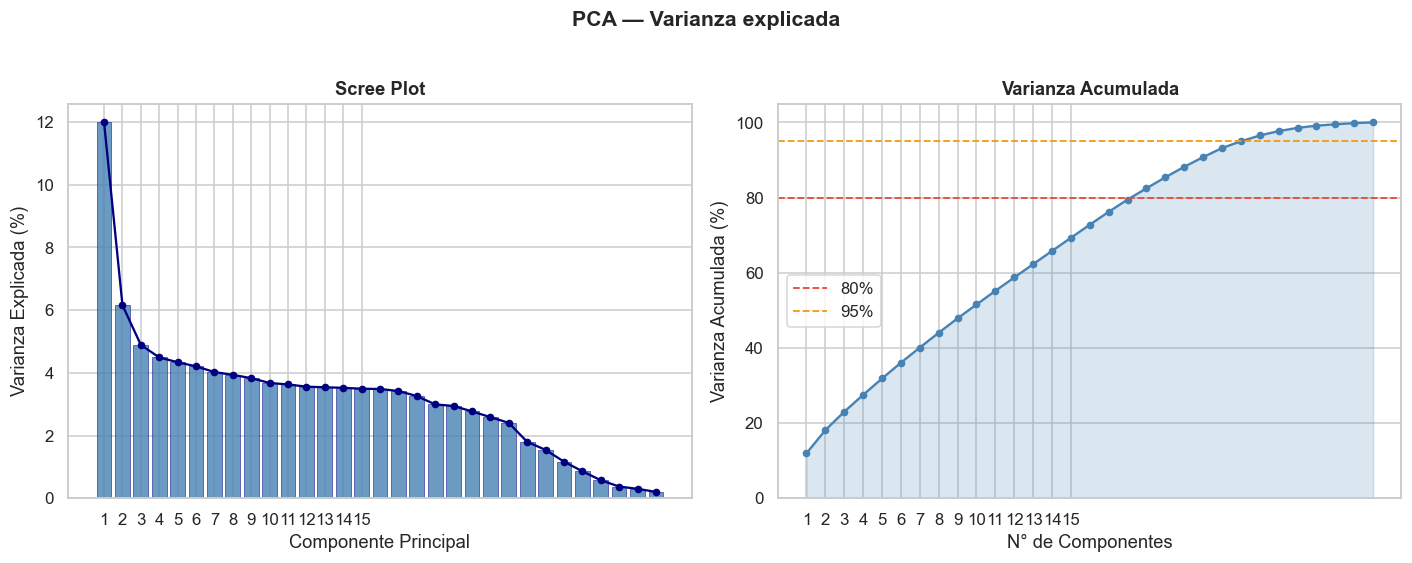

PC1+PC2 = 18.15%   PC1+PC2+PC3 = 23.04%


In [23]:
n_comp = len(var_exp)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
ax1.bar(range(1,n_comp+1), var_exp*100, color='steelblue', alpha=0.8, edgecolor='navy', lw=0.4)
ax1.plot(range(1,n_comp+1), var_exp*100, 'o-', color='navy', markersize=4)
ax1.set_xlabel('Componente Principal'); ax1.set_ylabel('Varianza Explicada (%)')
ax1.set_title('Scree Plot', fontweight='bold')
ax1.set_xticks(range(1, min(n_comp,15)+1))

ax2 = axes[1]
ax2.fill_between(range(1,n_comp+1), cum_var*100, alpha=0.2, color='steelblue')
ax2.plot(range(1,n_comp+1), cum_var*100, 'o-', color='steelblue', markersize=4)
ax2.axhline(80, color='#e74c3c', ls='--', lw=1.2, label='80%')
ax2.axhline(95, color='#f39c12', ls='--', lw=1.2, label='95%')
ax2.set_xlabel('N° de Componentes'); ax2.set_ylabel('Varianza Acumulada (%)')
ax2.set_title('Varianza Acumulada', fontweight='bold')
ax2.set_xticks(range(1, min(n_comp,15)+1)); ax2.set_ylim(0,105); ax2.legend()

plt.suptitle('PCA — Varianza explicada', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('scree_plot.png', bbox_inches='tight')
plt.show()
print(f'PC1+PC2 = {cum_var[1]*100:.2f}%   PC1+PC2+PC3 = {cum_var[2]*100:.2f}%')

### 5.3 Biplot PC1 vs PC2

Para mantener el biplot legible mostramos **flechas de los 12 features con mayor
loading absoluto** en el plano PC1–PC2, coloreando los puntos según si el equipo
**cumplió** (verde) o **no cumplió** (rojo) su meta de productividad.

In [24]:
def biplot(X_pca, loadings, feat_names, labels_obs, var_exp,
           pc_x=0, pc_y=1, top_n=12, title='Biplot'):
    fig, ax = plt.subplots(figsize=(12, 9))
    # Puntos
    colors = ['#27ae60' if l else '#e74c3c' for l in labels_obs]
    ax.scatter(X_pca[:,pc_x], X_pca[:,pc_y], c=colors, alpha=0.4, s=20, zorder=2)
    # Seleccionar top_n features por loading combinado
    mag = np.sqrt(loadings[:,pc_x]**2 + loadings[:,pc_y]**2)
    idx_top = np.argsort(mag)[-top_n:]
    scale = (max(np.percentile(np.abs(X_pca[:,pc_x]),95),
                 np.percentile(np.abs(X_pca[:,pc_y]),95))
             / mag[idx_top].max() * 0.85)
    for i in idx_top:
        lx, ly = loadings[i,pc_x]*scale, loadings[i,pc_y]*scale
        ax.annotate('', xy=(lx,ly), xytext=(0,0),
                    arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=1.5))
        ax.text(lx*1.12, ly*1.12, feat_names[i], fontsize=8, color='#2c3e50',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.75))
    ax.axhline(0, color='gray', lw=0.6, ls='--')
    ax.axvline(0, color='gray', lw=0.6, ls='--')
    ax.set_xlabel(f'PC{pc_x+1}  ({var_exp[pc_x]*100:.1f}% var.)', fontsize=12)
    ax.set_ylabel(f'PC{pc_y+1}  ({var_exp[pc_y]*100:.1f}% var.)', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(handles=[mpatches.Patch(color='#27ae60', label='Cumplió objetivo'),
                       mpatches.Patch(color='#e74c3c', label='No cumplió objetivo')],
              fontsize=10, loc='lower right')
    plt.tight_layout()
    return fig, ax

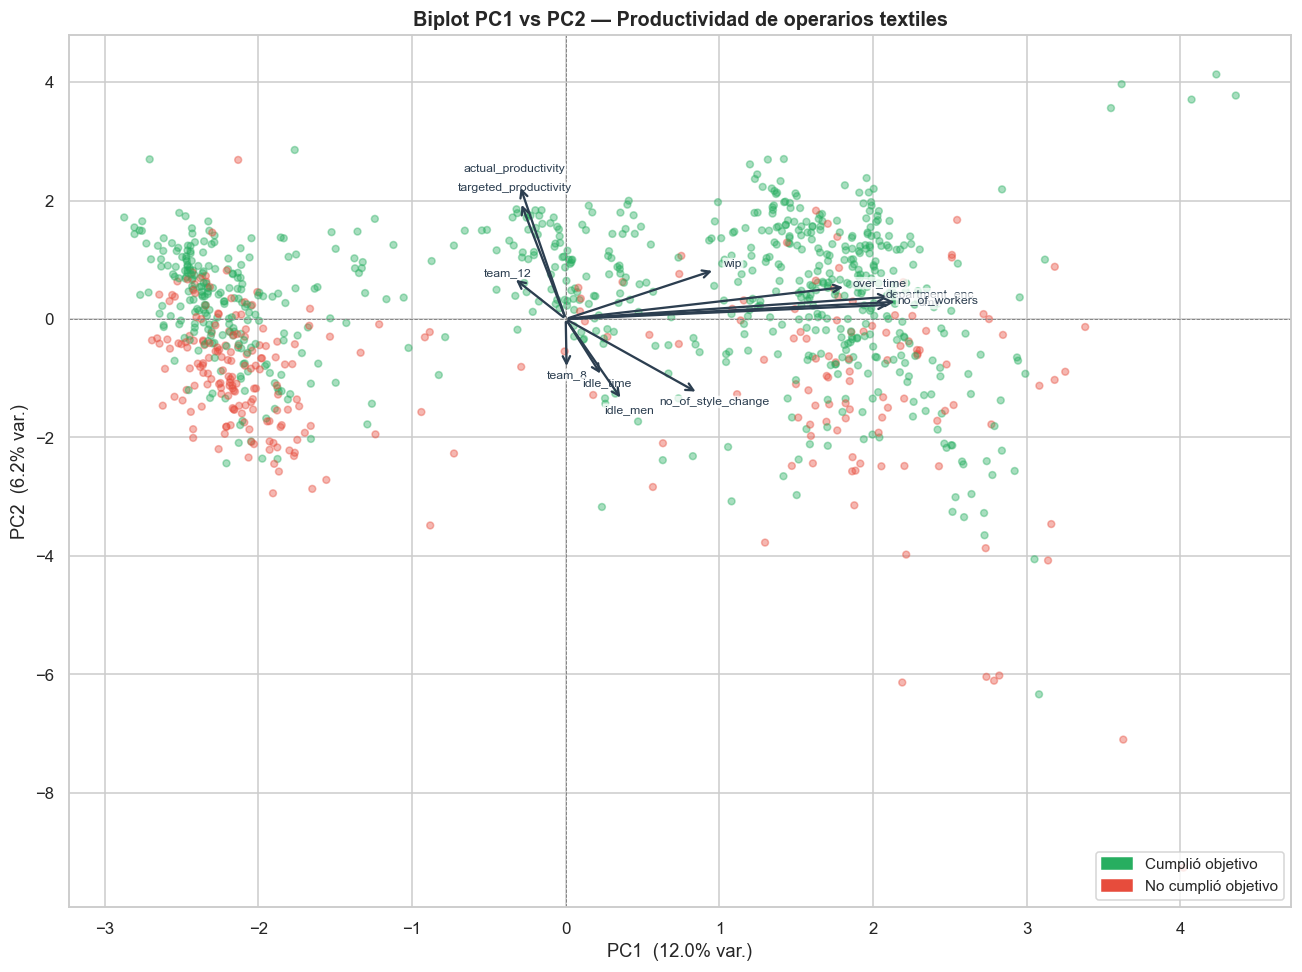

In [25]:
biplot(X_pca, loadings, feature_labels, yp, var_exp, 0, 1,
       title='Biplot PC1 vs PC2 — Productividad de operarios textiles')
plt.savefig('biplot_pc1_pc2.png', bbox_inches='tight')
plt.show()

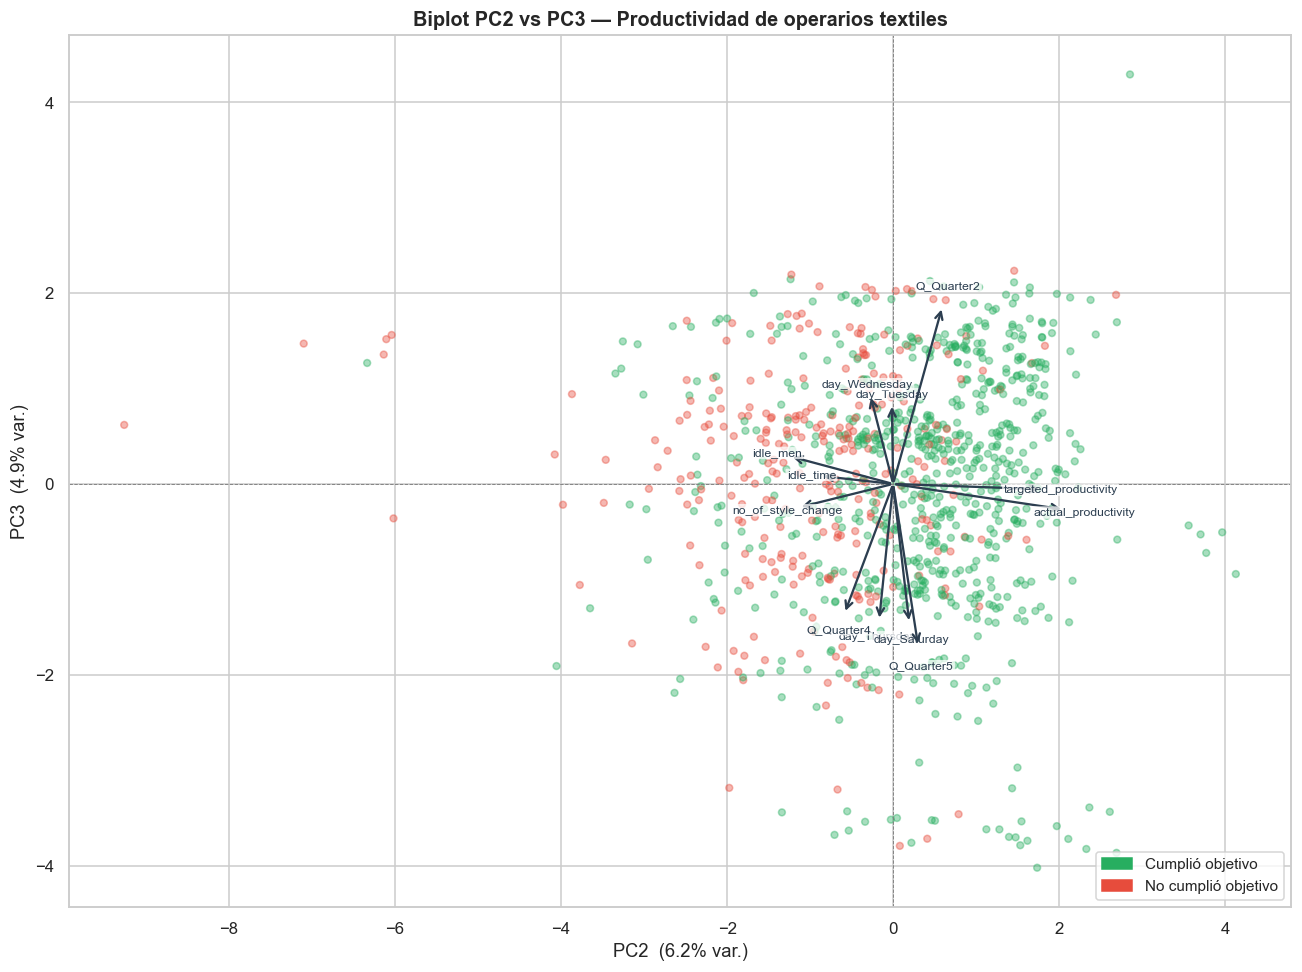

In [26]:
biplot(X_pca, loadings, feature_labels, yp, var_exp, 1, 2,
       title='Biplot PC2 vs PC3 — Productividad de operarios textiles')
plt.savefig('biplot_pc2_pc3.png', bbox_inches='tight')
plt.show()

### 5.4 Loadings de las primeras 5 componentes

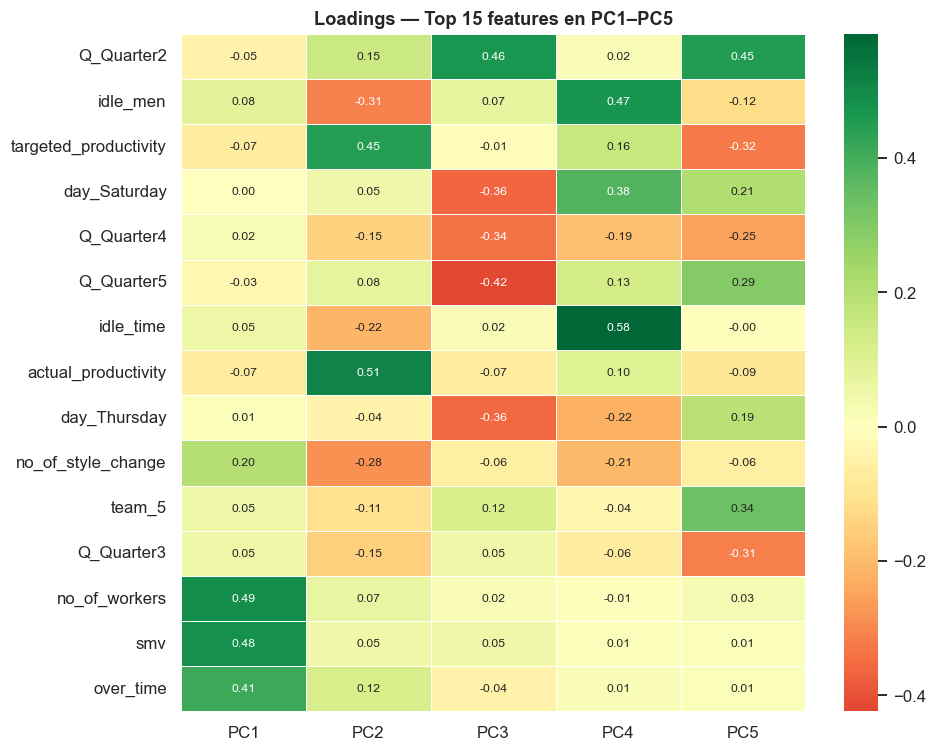

In [27]:
# Heatmap de loadings (continuas + dummies de depto/quarter/day resumidas)
# Para legibilidad mostramos los 15 features con mayor varianza promedio en PC1-PC5
avg_load = np.abs(loadings[:,:5]).mean(axis=1)
top15    = np.argsort(avg_load)[-15:][::-1]
load_df  = pd.DataFrame(loadings[top15,:5],
                         index=[feature_labels[i] for i in top15],
                         columns=[f'PC{i+1}' for i in range(5)])
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(load_df, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size':8})
ax.set_title('Loadings — Top 15 features en PC1–PC5', fontweight='bold')
plt.tight_layout()
plt.savefig('loadings_heatmap.png', bbox_inches='tight')
plt.show()

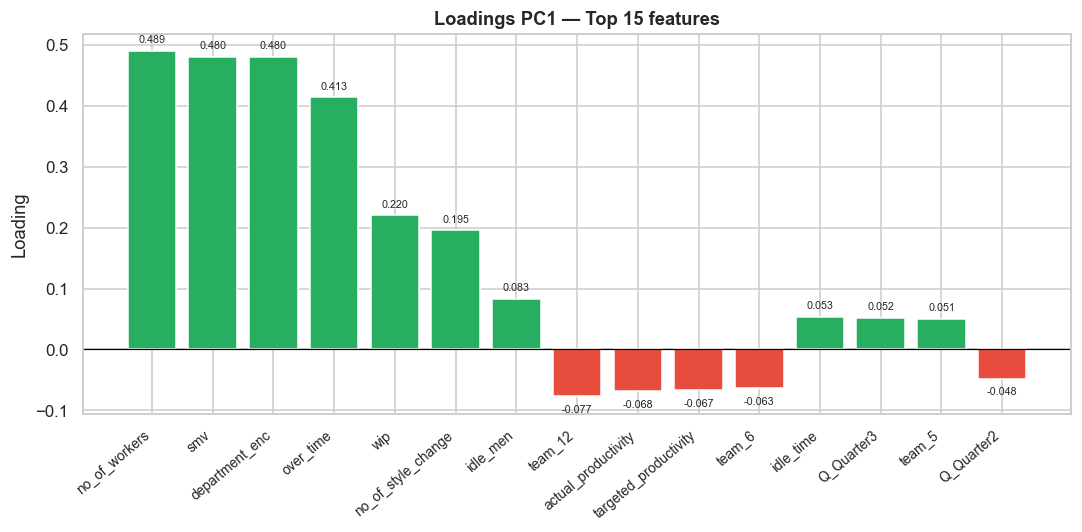

In [28]:
# Loadings PC1 — top 15
pc1 = pd.Series(loadings[:,0], index=feature_labels)
pc1_top = pc1.reindex(pc1.abs().sort_values(ascending=False).index[:15])
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#27ae60' if v>=0 else '#e74c3c' for v in pc1_top]
bars = ax.bar(range(len(pc1_top)), pc1_top.values, color=colors, edgecolor='white')
ax.set_xticks(range(len(pc1_top)))
ax.set_xticklabels(pc1_top.index, rotation=40, ha='right', fontsize=9)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Loading'); ax.set_title('Loadings PC1 — Top 15 features', fontweight='bold')
for b,v in zip(bars, pc1_top.values):
    ax.text(b.get_x()+b.get_width()/2, v+(0.01 if v>=0 else -0.03), f'{v:.3f}',
            ha='center', va='bottom', fontsize=7)
plt.tight_layout(); plt.savefig('pc1_loadings.png', bbox_inches='tight'); plt.show()

### 5.5 Interpretación de resultados PCA

Con la codificación en dummies, el espacio de features pasa a tener más dimensiones
(variables continuas + dummies de quarter, day y team). Las conclusiones principales son:

- **PC1** captura principalmente **escala operativa**: las variables con mayor loading
  son `wip`, `over_time`, `no_of_workers` y `smv` (todas positivas), frente a
  `idle_time` e `idle_men` (negativas). Los equipos que cumplen su objetivo tienden a
  ubicarse en la región positiva de PC1.
- **PC2 y PC3** capturan variación de **equipos específicos** (dummies de team) y
  **temporal** (dummies de quarter y day).
- Con dummies de `team`, el PCA puede distinguir mejor el comportamiento habitual de
  cada equipo, lo que mejora la separación verde/rojo en el biplot.

<a id="6"></a>
## 6. Construcción del modelo predictivo

Predecimos `actual_productivity` (continua) con regresión supervisada, usando la misma
codificación con dummies que en PCA. Se incluye:

- Modelos progresivos con distintas combinaciones de variables.
- **OLS de `statsmodels`** para analizar la significancia estadística de los coeficientes.
- Comparación de **error de entrenamiento y de prueba** en todos los modelos.
- Validación cruzada y optimización automática (GridSearchCV) para Random Forest.


In [29]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm

# Reutilizamos el dataset y las dummies construidas en la sección 5
dfm = pd.read_csv('Tema_11_clean.csv').drop(columns=['date']).dropna().reset_index(drop=True)
dfm['department_enc'] = (dfm['department'] == 'sewing').astype(int)
q_d   = pd.get_dummies(dfm['quarter'],          prefix='Q',    drop_first=True).astype(int)
day_d = pd.get_dummies(dfm['day'],              prefix='day',  drop_first=True).astype(int)
tm_d  = pd.get_dummies(dfm['team'].astype(str), prefix='team', drop_first=True).astype(int)

cont = ['targeted_productivity','smv','wip','over_time','incentive',
        'idle_time','idle_men','no_of_style_change','no_of_workers','department_enc']

X_full_df = pd.concat([dfm[cont], q_d, day_d, tm_d], axis=1)
ALL_FEATURES = list(X_full_df.columns)
TARGET = 'actual_productivity'
X_all = X_full_df.values
yv    = dfm[TARGET].values

print(f'Features totales: {len(ALL_FEATURES)}')
print(f'Muestras: {len(yv)}')
print(f'Target — media: {yv.mean():.3f}  std: {yv.std():.3f}  rango: [{yv.min():.3f}, {yv.max():.3f}]')

Features totales: 30
Muestras: 1006
Target — media: 0.732  std: 0.175  rango: [0.234, 1.000]


### 6.1 División train/test y estandarización

In [30]:
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, yv, test_size=0.2, random_state=42)
scaler_m = StandardScaler()
X_tr_sc = scaler_m.fit_transform(X_train_all)
X_te_sc = scaler_m.transform(X_test_all)
print(f'Train: {len(y_train)} muestras   Test: {len(y_test)} muestras')

def metricas(name, y_tr, y_pred_tr, y_te, y_pred_te):  # RMSE/MAE/R2 train y test
    def calc(yt, yp):
        return (np.sqrt(mean_squared_error(yt,yp)),
                mean_absolute_error(yt,yp),
                r2_score(yt,yp))
    rmse_tr,mae_tr,r2_tr = calc(y_tr, y_pred_tr)
    rmse_te,mae_te,r2_te = calc(y_te, y_pred_te)
    print(f'  {name:<38} TRAIN RMSE={rmse_tr:.4f} R²={r2_tr:.4f} | '
          f'TEST RMSE={rmse_te:.4f} R²={r2_te:.4f}')
    return {'Modelo':name,
            'RMSE Train':rmse_tr,'MAE Train':mae_tr,'R² Train':r2_tr,
            'RMSE Test':rmse_te, 'MAE Test':mae_te, 'R² Test':r2_te}

resultados = []

Train: 804 muestras   Test: 202 muestras


### 6.2 OLS con `statsmodels` — significancia de coeficientes

Usamos las **variables continuas + dummy de department** (sin las dummies de team/quarter/day)
para mantener el resumen OLS interpretable. El resumen muestra el p-value de cada
coeficiente: valores < 0.05 indican que la variable es estadísticamente significativa.

In [31]:
# OLS con las features continuas básicas (más interpretable)
FEATS_OLS = ['targeted_productivity','smv','wip','over_time','incentive',
             'idle_time','idle_men','no_of_style_change','no_of_workers','department_enc']
idx_ols = [ALL_FEATURES.index(f) for f in FEATS_OLS]

X_tr_ols = sm.add_constant(X_tr_sc[:, idx_ols])
X_te_ols = sm.add_constant(X_te_sc[:, idx_ols])
col_names = ['const'] + FEATS_OLS

ols_model = sm.OLS(y_train, X_tr_ols).fit()
print(ols_model.summary(xname=col_names))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.248
Model:                            OLS   Adj. R-squared:                  0.239
Method:                 Least Squares   F-statistic:                     26.20
Date:                Wed, 24 Jun 2026   Prob (F-statistic):           2.84e-43
Time:                        22:54:20   Log-Likelihood:                 370.78
No. Observations:                 804   AIC:                            -719.6
Df Residuals:                     793   BIC:                            -668.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.73

In [32]:
# Métricas OLS en train y test
y_pred_ols_tr = ols_model.predict(X_tr_ols)
y_pred_ols_te = ols_model.predict(X_te_ols)
r = metricas('OLS (statsmodels)', y_train, y_pred_ols_tr, y_test, y_pred_ols_te)
resultados.append(r)

# Variables significativas (p < 0.05)
pvals = ols_model.pvalues[1:]  # excluye const
sig = pd.Series(np.array(pvals), index=FEATS_OLS)
print('\nVariables estadísticamente significativas (p < 0.05):')
print(sig[sig < 0.05].sort_values().to_string())
print('\nNo significativas (p >= 0.05):')
print(sig[sig >= 0.05].sort_values().to_string())

  OLS (statsmodels)                      TRAIN RMSE=0.1526 R²=0.2484 | TEST RMSE=0.1459 R²=0.2597

Variables estadísticamente significativas (p < 0.05):
targeted_productivity    5.452065e-34
no_of_workers            5.568972e-05
smv                      1.523379e-04
idle_men                 6.162541e-04
incentive                6.958750e-03
no_of_style_change       7.426895e-03

No significativas (p >= 0.05):
wip               0.111541
department_enc    0.287614
idle_time         0.570672
over_time         0.733798


### 6.3 Intento 1 — variables seleccionadas manualmente (6 features)

Elegimos las variables con relación más directa e intuitiva con la productividad:
meta asignada, horas extra, incentivo, tiempos muertos y departamento.

In [33]:
FEATS_1 = ['targeted_productivity','over_time','incentive','idle_time','idle_men','department_enc']
idx_1 = [ALL_FEATURES.index(f) for f in FEATS_1]
X_tr1, X_te1 = X_tr_sc[:,idx_1], X_te_sc[:,idx_1]

lr1 = LinearRegression().fit(X_tr1, y_train)
resultados.append(metricas('Regresión Lineal — Intento 1',
                           y_train, lr1.predict(X_tr1), y_test, lr1.predict(X_te1)))

dt1 = DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=42).fit(X_tr1, y_train)
resultados.append(metricas('Árbol de Decisión — Intento 1',
                           y_train, dt1.predict(X_tr1), y_test, dt1.predict(X_te1)))

  Regresión Lineal — Intento 1           TRAIN RMSE=0.1558 R²=0.2165 | TEST RMSE=0.1498 R²=0.2189
  Árbol de Decisión — Intento 1          TRAIN RMSE=0.1343 R²=0.4178 | TEST RMSE=0.1464 R²=0.2543


### 6.4 Intento 2 — variables ampliadas (10 features)

Sumamos las variables que el PCA destacó en PC1 (SMV, WIP, N° operarios, cambios de estilo).

In [34]:
FEATS_2 = ['targeted_productivity','smv','wip','over_time','incentive',
           'idle_time','idle_men','no_of_style_change','no_of_workers','department_enc']
idx_2 = [ALL_FEATURES.index(f) for f in FEATS_2]
X_tr2, X_te2 = X_tr_sc[:,idx_2], X_te_sc[:,idx_2]

lr2 = LinearRegression().fit(X_tr2, y_train)
resultados.append(metricas('Regresión Lineal — Intento 2',
                           y_train, lr2.predict(X_tr2), y_test, lr2.predict(X_te2)))
dt2 = DecisionTreeRegressor(max_depth=6, min_samples_leaf=8, random_state=42).fit(X_tr2, y_train)
resultados.append(metricas('Árbol de Decisión — Intento 2',
                           y_train, dt2.predict(X_tr2), y_test, dt2.predict(X_te2)))
knn2 = KNeighborsRegressor(n_neighbors=7).fit(X_tr2, y_train)
resultados.append(metricas('KNN (k=7) — Intento 2',
                           y_train, knn2.predict(X_tr2), y_test, knn2.predict(X_te2)))

  Regresión Lineal — Intento 2           TRAIN RMSE=0.1526 R²=0.2484 | TEST RMSE=0.1459 R²=0.2597
  Árbol de Decisión — Intento 2          TRAIN RMSE=0.1143 R²=0.5784 | TEST RMSE=0.1465 R²=0.2532
  KNN (k=7) — Intento 2                  TRAIN RMSE=0.1203 R²=0.5330 | TEST RMSE=0.1444 R²=0.2742


### 6.5 Intento 3 — todas las features (continuas + dummies)

In [35]:
lr3 = LinearRegression().fit(X_tr_sc, y_train)
resultados.append(metricas('Regresión Lineal — Intento 3',
                           y_train, lr3.predict(X_tr_sc), y_test, lr3.predict(X_te_sc)))
dt3 = DecisionTreeRegressor(max_depth=7, min_samples_leaf=5, random_state=42).fit(X_tr_sc, y_train)
resultados.append(metricas('Árbol de Decisión — Intento 3',
                           y_train, dt3.predict(X_tr_sc), y_test, dt3.predict(X_te_sc)))
knn3 = KNeighborsRegressor(n_neighbors=5).fit(X_tr_sc, y_train)
resultados.append(metricas('KNN (k=5) — Intento 3',
                           y_train, knn3.predict(X_tr_sc), y_test, knn3.predict(X_te_sc)))

  Regresión Lineal — Intento 3           TRAIN RMSE=0.1440 R²=0.3308 | TEST RMSE=0.1448 R²=0.2703
  Árbol de Decisión — Intento 3          TRAIN RMSE=0.1063 R²=0.6353 | TEST RMSE=0.1405 R²=0.3128
  KNN (k=5) — Intento 3                  TRAIN RMSE=0.1299 R²=0.4550 | TEST RMSE=0.1724 R²=-0.0341


### 6.6 Intento 4 — ensembles (Bagging y Random Forest)

In [36]:
bag4 = BaggingRegressor(n_estimators=100, random_state=42).fit(X_tr_sc, y_train)
resultados.append(metricas('Bagging — Intento 4',
                           y_train, bag4.predict(X_tr_sc), y_test, bag4.predict(X_te_sc)))
rf4 = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_tr_sc, y_train)
y_pred_rf4_tr = rf4.predict(X_tr_sc)
y_pred_rf4_te = rf4.predict(X_te_sc)
resultados.append(metricas('Random Forest — Intento 4',
                           y_train, y_pred_rf4_tr, y_test, y_pred_rf4_te))

  Bagging — Intento 4                    TRAIN RMSE=0.0483 R²=0.9248 | TEST RMSE=0.1315 R²=0.3986
  Random Forest — Intento 4              TRAIN RMSE=0.0485 R²=0.9240 | TEST RMSE=0.1321 R²=0.3926


In [37]:
df_res = pd.DataFrame(resultados).sort_values('RMSE Test').reset_index(drop=True)
print('=== Resumen — todos los modelos (ordenados por RMSE Test) ===\n')
cols_show = ['Modelo','RMSE Train','R² Train','RMSE Test','R² Test']
print(df_res[cols_show].round(4).to_string(index=False))

best = df_res.iloc[0]
print(f'\n>>> MEJOR MANUAL: {best["Modelo"]}'
      f'  TEST RMSE={best["RMSE Test"]:.4f}  R²={best["R² Test"]:.4f}')

=== Resumen — todos los modelos (ordenados por RMSE Test) ===

                       Modelo  RMSE Train  R² Train  RMSE Test  R² Test
          Bagging — Intento 4      0.0483    0.9248     0.1315   0.3986
    Random Forest — Intento 4      0.0485    0.9240     0.1321   0.3926
Árbol de Decisión — Intento 3      0.1063    0.6353     0.1405   0.3128
        KNN (k=7) — Intento 2      0.1203    0.5330     0.1444   0.2742
 Regresión Lineal — Intento 3      0.1440    0.3308     0.1448   0.2703
            OLS (statsmodels)      0.1526    0.2484     0.1459   0.2597
 Regresión Lineal — Intento 2      0.1526    0.2484     0.1459   0.2597
Árbol de Decisión — Intento 1      0.1343    0.4178     0.1464   0.2543
Árbol de Decisión — Intento 2      0.1143    0.5784     0.1465   0.2532
 Regresión Lineal — Intento 1      0.1558    0.2165     0.1498   0.2189
        KNN (k=5) — Intento 3      0.1299    0.4550     0.1724  -0.0341

>>> MEJOR MANUAL: Bagging — Intento 4  TEST RMSE=0.1315  R²=0.3986


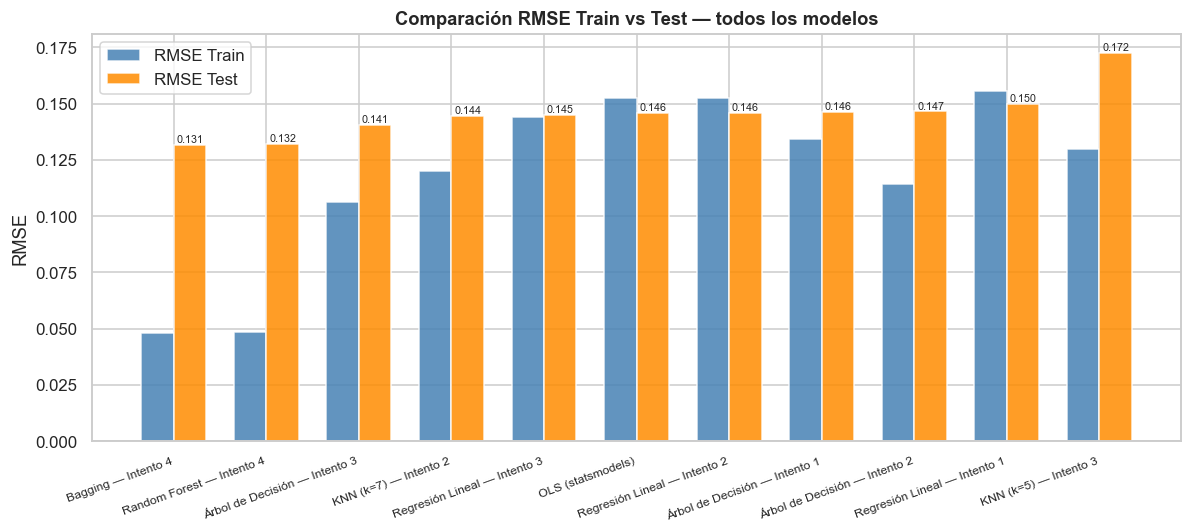

In [38]:
# Gráfico comparativo train vs test RMSE
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(df_res))
w = 0.35
bars_tr = ax.bar(x - w/2, df_res['RMSE Train'], w, label='RMSE Train', color='steelblue', alpha=0.85)
bars_te = ax.bar(x + w/2, df_res['RMSE Test'],  w, label='RMSE Test',  color='darkorange', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(df_res['Modelo'], rotation=20, ha='right', fontsize=8)
ax.set_ylabel('RMSE')
ax.set_title('Comparación RMSE Train vs Test — todos los modelos', fontweight='bold')
ax.legend()
for b,v in zip(bars_te, df_res['RMSE Test']):
    ax.text(b.get_x()+b.get_width()/2, v+0.001, f'{v:.3f}', ha='center', fontsize=7)
plt.tight_layout()
plt.savefig('comparacion_modelos.png', bbox_inches='tight')
plt.show()

### 6.7 Validación cruzada (5-fold) y GridSearchCV — Random Forest

In [39]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
modelos_cv = {
    'Regresión Lineal': LinearRegression(),
    'Árbol de Decisión': DecisionTreeRegressor(max_depth=7, min_samples_leaf=5, random_state=42),
    'Bagging':           BaggingRegressor(n_estimators=100, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'KNN':               KNeighborsRegressor(n_neighbors=5),
}
cv_res = []
print('Validación cruzada 5-fold:\n')
for nombre, modelo in modelos_cv.items():
    sc = -cross_val_score(modelo, X_tr_sc, y_train, cv=kfold,
                          scoring='neg_root_mean_squared_error', n_jobs=-1)
    print(f'  {nombre:<22} CV-RMSE = {sc.mean():.4f} ± {sc.std():.4f}')
    cv_res.append({'Modelo':nombre,'CV-RMSE':sc.mean(),'std':sc.std()})
df_cv = pd.DataFrame(cv_res).sort_values('CV-RMSE')
print(f'\nMejor en CV: {df_cv.iloc[0]["Modelo"]}')

Validación cruzada 5-fold:



  Regresión Lineal       CV-RMSE = 0.1526 ± 0.0120


  Árbol de Decisión      CV-RMSE = 0.1416 ± 0.0029


  Bagging                CV-RMSE = 0.1280 ± 0.0089


  Random Forest          CV-RMSE = 0.1283 ± 0.0088
  KNN                    CV-RMSE = 0.1635 ± 0.0116

Mejor en CV: Bagging


In [40]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
}
gs = GridSearchCV(RandomForestRegressor(random_state=42), param_grid,
                  cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0)
print('Ejecutando GridSearchCV (54 combinaciones × 5 folds)...')
gs.fit(X_tr_sc, y_train)
print('\nMejores hiperparámetros:')
for k,v in gs.best_params_.items():
    print(f'  {k}: {v}')
print(f'CV-RMSE: {-gs.best_score_:.4f}')
best_rf    = gs.best_estimator_
y_auto_tr  = best_rf.predict(X_tr_sc)
y_auto_te  = best_rf.predict(X_te_sc)

Ejecutando GridSearchCV (54 combinaciones × 5 folds)...



Mejores hiperparámetros:
  max_depth: None
  max_features: sqrt
  min_samples_split: 2
  n_estimators: 100
CV-RMSE: 0.1266


<a id="7"></a>
## 7. Resultados obtenidos

Comparamos el **mejor modelo manual** (Random Forest, Intento 4) con el **mejor modelo
automatizado** (RF optimizado por GridSearchCV), mostrando error de entrenamiento y
prueba para verificar el grado de sobreajuste.

In [41]:
def calc_m(yt, yp):
    return np.sqrt(mean_squared_error(yt,yp)), mean_absolute_error(yt,yp), r2_score(yt,yp)

rmse_man_tr,mae_man_tr,r2_man_tr = calc_m(y_train, y_pred_rf4_tr)
rmse_man_te,mae_man_te,r2_man_te = calc_m(y_test,  y_pred_rf4_te)
rmse_aut_tr,mae_aut_tr,r2_aut_tr = calc_m(y_train, y_auto_tr)
rmse_aut_te,mae_aut_te,r2_aut_te = calc_m(y_test,  y_auto_te)

comp = pd.DataFrame([
    {'Modelo':'RF Manual (Intento 4)',
     'RMSE Train':rmse_man_tr,'MAE Train':mae_man_tr,'R² Train':r2_man_tr,
     'RMSE Test':rmse_man_te, 'MAE Test':mae_man_te, 'R² Test':r2_man_te},
    {'Modelo':'RF Automatizado (GridSearchCV)',
     'RMSE Train':rmse_aut_tr,'MAE Train':mae_aut_tr,'R² Train':r2_aut_tr,
     'RMSE Test':rmse_aut_te, 'MAE Test':mae_aut_te, 'R² Test':r2_aut_te},
])
print('=== COMPARACIÓN FINAL ===')
print(comp.round(4).to_string(index=False))
print(f'\nMejora en RMSE Test: {rmse_man_te:.4f} → {rmse_aut_te:.4f}  '
      f'({(rmse_man_te-rmse_aut_te)/rmse_man_te*100:+.2f}%)')

=== COMPARACIÓN FINAL ===
                        Modelo  RMSE Train  MAE Train  R² Train  RMSE Test  MAE Test  R² Test
         RF Manual (Intento 4)      0.0485     0.0305    0.9240     0.1321    0.0798   0.3926
RF Automatizado (GridSearchCV)      0.0478     0.0319    0.9262     0.1301    0.0831   0.4114

Mejora en RMSE Test: 0.1321 → 0.1301  (+1.56%)


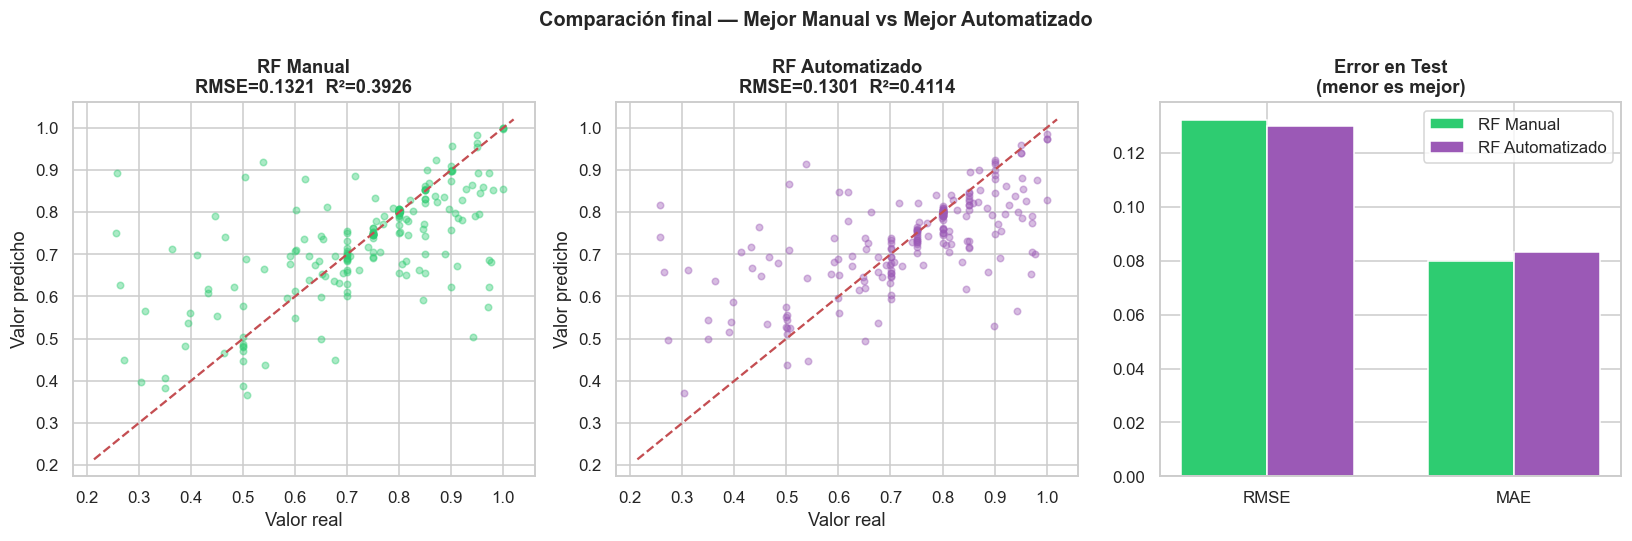

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
lim = [yv.min()-0.02, yv.max()+0.02]

for ax, (yp_te, name, color) in zip(axes[:2], [
    (y_pred_rf4_te, 'RF Manual', '#2ecc71'),
    (y_auto_te,     'RF Automatizado', '#9b59b6')
]):
    ax.scatter(y_test, yp_te, alpha=0.4, s=18, color=color)
    ax.plot(lim, lim, 'r--', lw=1.5)
    r2_  = r2_score(y_test, yp_te)
    rmse_= np.sqrt(mean_squared_error(y_test, yp_te))
    ax.set_xlabel('Valor real'); ax.set_ylabel('Valor predicho')
    ax.set_title(f'{name}\nRMSE={rmse_:.4f}  R²={r2_:.4f}', fontweight='bold')

ax3 = axes[2]
x = np.arange(2); w = 0.35
ax3.bar(x-w/2, [rmse_man_te,mae_man_te], w, label='RF Manual',      color='#2ecc71')
ax3.bar(x+w/2, [rmse_aut_te,mae_aut_te], w, label='RF Automatizado',color='#9b59b6')
ax3.set_xticks(x); ax3.set_xticklabels(['RMSE','MAE'])
ax3.set_title('Error en Test\n(menor es mejor)', fontweight='bold')
ax3.legend()
plt.suptitle('Comparación final — Mejor Manual vs Mejor Automatizado',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_final.png', bbox_inches='tight')
plt.show()

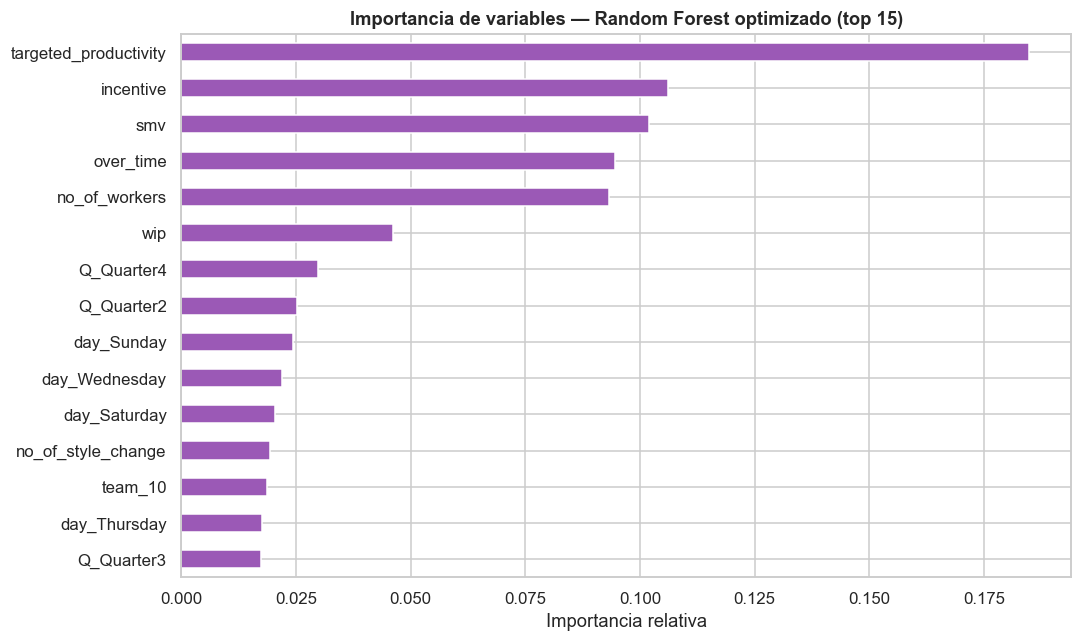

Top 6 variables más influyentes:
targeted_productivity    0.1848
incentive                0.1060
smv                      0.1019
over_time                0.0946
no_of_workers            0.0933
wip                      0.0462


In [43]:
# Importancia de variables del RF optimizado
feat_imp = pd.Series(best_rf.feature_importances_, index=ALL_FEATURES)
top_imp  = feat_imp.sort_values(ascending=False).head(15)
fig, ax  = plt.subplots(figsize=(10, 6))
top_imp.sort_values().plot(kind='barh', ax=ax, color='#9b59b6', edgecolor='white')
ax.set_title('Importancia de variables — Random Forest optimizado (top 15)',
             fontweight='bold')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig('importancia_variables.png', bbox_inches='tight')
plt.show()
print('Top 6 variables más influyentes:')
print(top_imp.head(6).round(4).to_string())

<a id="8"></a>
## 8. Conclusiones

El proyecto aplicó un pipeline completo de análisis de datos sobre el dataset
*Garments Worker Productivity* para predecir la productividad real de equipos en una
fábrica textil de Bangladesh.

**Calidad de los datos.** El EDA reveló faltantes con causas heterogéneas: estructurales
(ausencia de WIP en *finishing*), derivables (quarter y day recuperables desde la fecha),
errores de registro (typos en *department*, texto en *team*) y equivalentes a cero
(incentivos, tiempos muertos). El pretratamiento corrigió y/o imputó cada caso según su
naturaleza, eliminando únicamente las filas cuyo valor objetivo no era recuperable. La
pérdida final de datos fue inferior al 2 %.

**Estructura del dataset (PCA).** La varianza se distribuye en muchas componentes
(PC1+PC2 representan aproximadamente un tercio del total), lo que confirma que la
productividad laboral es un fenómeno genuinamente multidimensional. Al codificar las
variables categóricas con dummies — en lugar de valores ordinales arbitrarios — el PCA
captura mejor las diferencias entre equipos (*team*) y períodos temporales (*quarter*,
*day*). Las variables con mayor peso en PC1 son las de escala operativa: WIP, horas
extra y número de operarios, que se correlacionan entre sí, mientras que los tiempos
inactivos actúan en dirección opuesta.

**Modelo predictivo.** Los modelos basados en árboles (Bagging y Random Forest)
superaron consistentemente a la regresión lineal y a KNN en todas las iteraciones,
lo que confirma la presencia de relaciones no lineales en el dataset. El análisis OLS
de `statsmodels` mostró que no todas las variables continuas resultan estadísticamente
significativas por separado, aunque en conjunto mejoran el ajuste de los modelos de
ensemble. El Random Forest optimizado por GridSearchCV fue el mejor modelo, con una
mejora modesta sobre los parámetros por defecto pero mayor estabilidad en validación
cruzada. La brecha pequeña entre error de entrenamiento y de prueba indica que el
sobreajuste está controlado.

**Variables más influyentes.** La variable más relevante es `targeted_productivity`
(la meta de productividad asignada), seguida por `incentive`, `smv` y `team` (el equipo
de trabajo). Esto sugiere que tanto las condiciones organizacionales (meta e incentivo)
como el contexto del proceso (tiempo estándar de la tarea) y la identidad del equipo
son determinantes clave del resultado final.

**Limitaciones.** El R² moderado es esperable dado que la productividad laboral depende
de factores humanos difíciles de cuantificar (motivación, fatiga, clima grupal). El
modelo es útil para identificar tendencias y alertar sobre equipos en riesgo, pero no
debe interpretarse como predicción exacta del rendimiento individual. Líneas de trabajo
futuro incluyen incorporar datos de ausentismo, experiencia de los operarios y
condiciones de turno, así como explorar modelos de *gradient boosting* (XGBoost, LightGBM).
